In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Cinética de Procesos (Sesión 05)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

## 2. Modelo de nucleo decreciente

## 2.1 Descripción del modelo

### 2.1.1 Descripción general

En este modelo, una partícula sólida de material $\mathrm{B}$, con radio inicial $R$ reacciona con un fluido. A lo largo de la reacción el radio externo de la partícula, $R$, es constante. Conforme la reacción procede y el reactivo $\mathrm{B}$ se consume, el radio del nucleo de la partícula, $r_c$, disminuye. Si la conversión es completa, se tiene una partícula de radio $R$ contituida por el(los) producto(s) de reacción.
El modelo se esquematiza en la debajo:

<center>

<img src="figures/images/shrinking_core_schematic.png" style="width:600px" title="shrinkingCore">

***Figura 01. Esquema del modelo de nucleo decreciente.*** 


</center>

**Aplicaciones posibles:**

- Tostación de minerales.
- Reducción directa.
- Nitrurado.
- Capas de protección superficial.

### 2.1.2 Conversión

La conversión se relaciona directamente con el tamaño del núcleo decreciente, $r_c$ con respecto al tamaño global de la partícula $R$ (constante).

$$X_{\mathrm{B}} = 1 - \left(\frac{r_c}{R}\right)^3

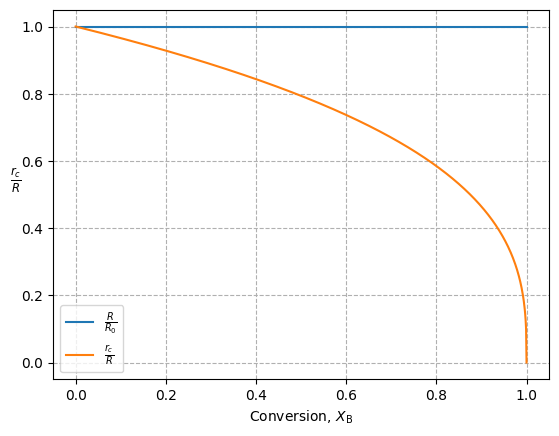

In [12]:
fig, ax = plt.subplots()
xB = np.linspace(0, 1, 1001)
rC = np.power(1-xB, 1/3)
ax.plot(xB, np.ones_like(xB), label=r"$\frac{R}{R_0}$")
ax.plot(xB, rC, label=r"$\frac{r_c}{R}$")
ax.set_xlabel(r"Conversion, $X_{\mathrm{B}}$")
ax.set_ylabel(r"$\frac{r_c}{R}$", rotation=0, fontsize=12)
ax.legend()
ax.grid(ls='--')
plt.show()

### 2.1.3 Fenomenología

La fenomenología del modelo consta de 5 etapas que incluyen los procesos difusivos de reactivos y productos, y la reacción que ocurre en la superficie que delimita la capa de productos y el nucleo decreciente:

- **Etapa 1:** Difusión del reactivo $\mathrm{A}$ a través de la capa límite formada alrededor de la superficie de la partícula, hacia el interior.

- **Etapa 2:** Penetración y difusión del $\mathrm{A}$ a través del producto de reacción sólido (poroso), hasta la superficie del núcleo no reaccionado.

- **Etapa 3:** Reacción de $\mathrm{A}$ con $\mathrm{B}$ en la superficie de reacción.

- **Etapa 4:** Difusión de especies a través del producto de reacción sólido (poroso), hasta la superficie exterior de la partícula.

- **Etapa 5:** Difusión de especies a través de la capa límite formada alrededor de la superficie de la partícula, hacia el exterior.

Cada una de estas etapas ocurre de manera simultanea, y se puede considerar conceptualmente como un conjunto de resistencias en serie. Entonces, el tiempo requerido para que ocurra un cierto nivel de conversión es igual a la suma de las contribuciones de cada etapa:

$$t_{\text{total}} = \underbrace{t_{\text{capa límite}}}_{\text{Etapas: 1, 5}} + \underbrace{t_{\text{capa productos}}}_{\text{Etapas: 2, 4}} + \underbrace{t_{\text{reacción}}}_{\text{Etapa 3}}$$

De igual forma, el tiempo característico para lograr la conversión total es:

$$\tau_{\text{total}} = \underbrace{\tau_{\text{capa límite}}}_{\text{Etapas: 1, 5}} + \underbrace{\tau_{\text{capa productos}}}_{\text{Etapas: 2, 4}} + \underbrace{\tau_{\text{reacción}}}_{\text{Etapa 3}}$$

## 2.2 Ecuaciones del modelo

### 2.2.1 Ecuación diferencial con tiempos característicos

**Ecuación general**

El modelo general considera la contribución individual de cada mecanismo (difusión de especies en la capa límite, difusión de especies en la capa de productos, y reacción en la superficie de reacción), como términos resistivos en una ecuación transitoria que describe el flujo molar de la especie $\mathrm{B}$ en la interfase entre el núcleo decreciente y la capa de productos:

$$-\frac{1}{S_{\mathrm{ex}}} \frac{dN_\mathrm{B}}{dt} = \frac{\displaystyle b C_{\mathrm{A}}}{\displaystyle \underbrace{\frac{1}{k_{\mathrm{g}}}}_{\text{capa límite}} + \underbrace{\frac{R(R-r_c)}{r_c D_e}}_{\text{capa productos}} + \underbrace{\frac{R^2}{r_c^2 k^{\prime \prime}}}_{\text{reacción}}}$$



**Ecuación para en términos del radio del nucleo decreciente**

Para una geometría esférica, el volumen del núcleo decreciente y la superficie de la interfase estan dadas por:

$$V_c = \frac{4}{3} \pi r_c^3$$

$$S_{\mathrm{ex}} = 4\pi r_c^2$$

y el cambio diferencial de la cantidad de especie $\mathrm{B}$, $dN_{\mathrm{B}}$, está dado por:

$$dN_{\mathrm{B}} = \rho_{B} dV_c = \rho_{B} \cdot 4 \pi r_c^2 dr_c$$


La ecuación se puede entonces escribir en términos del radio del núcleo decreciente:

$$-\frac{dr_c}{dt} = \frac{\displaystyle \frac{b C_{\mathrm{A}}}{\rho_{B}}}{\displaystyle \underbrace{\frac{r_c^2}{R^2 k_{\mathrm{g}}}}_{\text{capa límite}} + \underbrace{\frac{(R-r_c)r_c}{R D_{e}}}_{\text{capa reacción}} + \underbrace{\frac{1}{k^{\prime \prime}}}_{\text{reacción}}}$$

<details>
<summary><b>Nomenclatura</b></summary>

<div class="alert alert-info">

- **$t$**: tiempo, $\mathrm{[s]}$.

- **$\tau$**: tiempo característico, $\mathrm{[s]}$.

- **$X_{\mathrm{B}}$**: conversión.

- **$\rho_{\mathrm{B}}$**: densidad molar del reactivo $\mathrm{B}$, $\mathrm{[mol.m^{-3}]}$.

- **$R$**: radio inicial de la partícula, $\mathrm{[m]}$.

- **$b$**: coeficiente estequiométrico de la reacción.

- **$k_{\mathrm{g}}$**: coeficiente de transferencia de masa entre fluido y partícula, $\mathrm{[m.s^{-1}]}$.

- **$D_{e}$**: coeficiente de difusión efectiva en la capada de productos porosos, $\mathrm{[m^2.s^{-1}]}$.

- **$k^{\prime \prime}$**: constante de reacción en la superficie (1er orden), $\mathrm{[m.s^{-1}]}$.

- **$C_{\mathrm{A}}$**: Concentración de $\mathrm{A}$, $\mathrm{mol.m^{-3}}$.

</div>

</details>

In [13]:
def shrinking_core(t, rc, R, rhoB, b, cA, kg, De, kpp):
    r1 = rc**2/(R**2 * kg)
    r2 = ((R-rc)*rc)/(R*De)
    r3 = 1/kpp
    return -(b*cA/rhoB) / (r1 + r2 + r3)
def shrinking_core_end(t, rc, R, rhoB, b, cA, kg, De, kpp):
    return rc[0]
shrinking_core_end.terminal=True

### 2.2.2 Soluciones analíticas para distintas etapas limitantes

Si se asume que un solo mecanismo es preponderante, i.e., es la étapa limitante, existen expresiones algebráicas individuales:

#### 2.2.2.1 Difusión en la capa límite

$$\frac{t}{\tau} = X_{\mathrm{B}}$$

$$\tau = \frac{\rho_{\mathrm{B}}R}{3 b \, k_{\mathrm{g}} \, C_{\mathrm{A,g}}}$$

In [14]:
def shrinking_core_boundary_layer(xB, R, rhoB, b, cA, kg):
    tau = (rhoB*R) / (3*b*kg*cA)
    RHS = xB
    return RHS*tau

#### 2.2.2.2 Difusión a través de la capa de productos

$$\frac{t}{\tau} = 1 - 3 \left(1 - X_{\mathrm{B}}\right)^{\frac{2}{3}} + 2 \left(1 - X_{\mathrm{B}}\right)$$

$$\tau = \frac{\rho_{\mathrm{B}}R^2}{6 b \, D_{e} \, C_{\mathrm{A,g}}}$$

In [15]:
def shrinking_core_product_layer(xB, R, rhoB, b, cA, De):
    tau = (rhoB*R**2) / (6*b*De*cA)
    RHS = 1 - 3*np.power(1-xB,2/3) + 2*(1-xB)
    return RHS*tau

#### 2.2.2.3 Reacción química

$$\frac{t}{\tau} = 1 - \left( 1 - X_{\mathrm{B}} \right)^{\frac{1}{3}}$$

$$\tau = \frac{\rho_{\mathrm{B}}R}{b \, k^{\prime \prime} \, C_{\mathrm{A,g}}}$$

In [16]:
def shrinking_core_reaction(xB, R, rhoB, b, cA, kpp):
    tau = (rhoB*R) / (b*kpp*cA)
    RHS = 1 - np.power(1-xB, 1/3)
    return RHS*tau

## 2.3 Comparación

In [17]:
# relation between conversion and radius of the core
xB = np.linspace(0, 1, 1001)
rc = R*np.power(1-xB, 1/3)

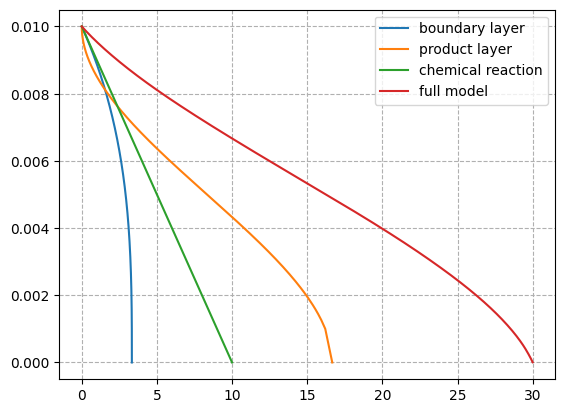

In [21]:
# parameters
R = 0.01 # m
rhoB = 1 #mol/m3
b = 1
cA = 1 # mol/m3
kg = 1e-3
De = 1e-6
kpp = 1e-3

# shrinking core model for diffusion in boundary layer as limiting step
tbound = shrinking_core_boundary_layer(xB, R, rhoB, b, cA, kg)
# shrinking core model for diffusion in product layer as limiting step
tprod = shrinking_core_product_layer(xB, R, rhoB, b, cA, De)
# shrinking core model for chemical reaction as limiting step
treac = shrinking_core_reaction(xB, R, rhoB, b, cA, kpp)
# full model
t_span = (0, 40)
ndt = 1001
t_eval = np.linspace(t_span[0], t_span[1], ndt)
sol = solve_ivp(
    shrinking_core,
    t_span = t_span,
    y0 = (R,),
    args=(R, rhoB, b, cA, kg, De, kpp),
    t_eval = t_eval,
    events = shrinking_core_end
)
tfull, rfull = sol.t, sol.y[0]

fig, ax = plt.subplots()
ax.plot(tbound, rc, label='boundary layer')
ax.plot(tprod, rc, label='product layer')
ax.plot(treac, rc, label='chemical reaction')
ax.plot(tfull, rfull, label='full model')
ax.legend()
ax.grid(ls='--')
plt.show()

In [ ]:

print(tbound[-1]+tprod[-1]+treac[-1], tfull[-1])

30.0 30.0
